In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
M_regular_results = pd.read_csv("MRegularSeasonDetailedResults.csv")
M_tourney_results = pd.read_csv("MNCAATourneyDetailedResults.csv")
M_seeds = pd.read_csv("MNCAATourneySeeds.csv")

In [83]:
CUTOFF_YEAR = 2006

regular_results = M_regular_results.loc[M_regular_results["Season"] >= CUTOFF_YEAR]
tourney_results = M_tourney_results.loc[M_tourney_results["Season"] >= CUTOFF_YEAR]
seeds = M_seeds.loc[M_seeds["Season"] >= CUTOFF_YEAR]

#### Meaning of each columns in MRegularSeasonDetailedResults.csv:
* Season: the season year. 2001 means the tournament was played in the 2000/01 season
* DayNum: day index within the season. smaller - earlier games, larger = later games.
* WTeamID: winning team ID
* WScore: points scored by the winner
* LTeamID: losing team ID
* LScore: points scored by loser
* WLoc: location from winner's perspective: H means home, A means away, N means neutral
* NumOT: number of overtime periods. 0 means normal, no OT
* WFGM: field goals made, both 2 and 3pt
* WFGA: field goals attempted, both 2 and 3 pt
* WFGM3: 3 pointers made
* WFGA3: 3 pointers attempted
* WFTM: free throws made
* WFTA: free throws attempted
* WOR: offensive rebounds (own missed shots)
* WDR: defensive rebounds (opponent missed shots)
* total rebounds = WOR + WDR
* WAst: assists
* WTO: number of turnovers
* WStl: number of steals
* WBlk: number of blocks
* WPF: number of personal fouls
* The rest of the columns are the same, just L instead of W meaning for the losing team instead.

#### Meaning of each column in MNCAATourneyDetailResults.csv:
* Season, daynum, WteamID, WScore, LTeamID, Lscore, WLoc, NumOT, all W... stats and L... stats same as above.

#### Meaning of each column in MNCAATourneySeeds.csv:
* Season: tournamet year
* Seed: strings like W01, X08, W16a. First letter is the region, next 2 digits is the seed number (01 is best, 16 is worst team), optional a/b suffix means play-in teams

In [84]:
regular_results.head()

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,...,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
13862,2006,8,1165,75,1384,54,N,0,24,54,...,20,11,17,11,19,11,12,5,4,18
13863,2006,8,1393,68,1126,37,H,0,21,44,...,13,4,9,12,19,10,23,13,1,24
13864,2006,9,1107,90,1324,73,N,0,35,62,...,25,7,12,18,16,13,18,11,7,15
13865,2006,9,1126,63,1384,52,N,1,22,59,...,26,12,19,20,35,11,17,3,4,16
13866,2006,9,1196,80,1389,51,H,0,29,54,...,18,3,8,16,22,10,17,4,0,20


In [85]:
tourney_results.head()

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,...,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
192,2006,134,1284,71,1214,49,N,0,27,61,...,15,7,13,15,27,7,13,4,4,11
193,2006,136,1104,90,1266,85,N,0,28,55,...,22,14,19,13,15,13,12,9,4,22
194,2006,136,1130,88,1334,76,N,2,29,57,...,25,14,18,14,23,18,15,4,2,22
195,2006,136,1181,70,1380,54,N,0,24,49,...,13,6,10,16,16,8,16,14,4,20
196,2006,136,1196,76,1375,50,N,0,29,59,...,20,3,6,7,24,8,16,7,3,17


In [86]:
seeds.head()

,Season,Seed,TeamID
1349,2006,W01,1181
1350,2006,W02,1400
1351,2006,W03,1234
1352,2006,W04,1261
1353,2006,W05,1393


## Phase 1: data structuring

### 1a: Build Matchups

Our current dataset has stats for the W teamID and L teamID, which indirect exposes who was the winning and losing team. This is supposed to be kept a secret and is what we have to decide on. 

Thus, we need to reformulate the columns to hide winning and losing information. we can change it by creating teamA/teamB rows, and a column called Y that says 1 means team A won, 0 means team B won. we will then have to also shuffle the rows if not it would look like either all of team A and all of team B wins all the time because they were directly taken from WTeamID and LTeamID.

In [87]:
games_a = pd.DataFrame({
    "Season": tourney_results["Season"],
    "DayNum": tourney_results["DayNum"],
    "TeamA": tourney_results["WTeamID"],
    "TeamB": tourney_results["LTeamID"],
    "Y": 1
})

games_b = pd.DataFrame({
    "Season": tourney_results["Season"],
    "DayNum": tourney_results["DayNum"],
    "TeamA": tourney_results["LTeamID"],
    "TeamB": tourney_results["WTeamID"],
    "Y": 0
})

# Combine both
matchups = pd.concat([games_a, games_b], ignore_index=True)

# Shuffle rows
matchups = matchups.sample(frac=1, random_state=42).reset_index(drop=True)


print(matchups.head())
print(matchups["Y"].value_counts())


   Season  DayNum  TeamA  TeamB  Y
0    2009     137   1199   1458  0
1    2021     146   1166   1211  0
2    2018     137   1308   1155  0
3    2018     136   1460   1397  0
4    2023     139   1211   1395  1
Y
0    1190
1    1190
Name: count, dtype: int64


### 1b. add the first feature: seeds
* as mentioned earlier, each team has a seed from the seeds.csv like: "W01" --> Seed 1 (very strong), and 16 is the weakest.
* we want to create for every matchup, the seed number of teamA and seed number of team B. then another column which is seedDiff = teamAseed-teamBseed

In [88]:
seeds.head()

,Season,Seed,TeamID
1349,2006,W01,1181
1350,2006,W02,1400
1351,2006,W03,1234
1352,2006,W04,1261
1353,2006,W05,1393


In [89]:
seeds["SeedNum"] = seeds["Seed"].str.extract(r'(\d{2})').astype(int)
seeds_clean = seeds[["Season", "TeamID", "SeedNum"]]

# Merge for teamA via left join
matchups = matchups.merge(seeds_clean, left_on=["Season", "TeamA"], right_on=["Season", "TeamID"], how="left").rename(columns={"SeedNum": "TeamA_Seed"})
matchups = matchups.drop(columns=["TeamID"])

# Merge teamB via leftJoin also
matchups = matchups.merge(seeds_clean, left_on=["Season", "TeamB"], right_on=["Season", "TeamID"], how="left").rename(columns={"SeedNum": "TeamB_Seed"})
matchups = matchups.drop(columns=["TeamID"])

# seedDiff
matchups["SeedDiff"] = matchups["TeamA_Seed"] - matchups["TeamB_Seed"] 

# print(matchups[["TeamA_Seed", "TeamB_Seed", "SeedDiff"]].head())
# print(matchups.isnull().sum())

matchups

,Season,DayNum,TeamA,TeamB,Y,TeamA_Seed,TeamB_Seed,SeedDiff
0,2009,137,1199,1458,0,5,12,-7
1,2021,146,1166,1211,0,5,1,4
2,2018,137,1308,1155,0,12,5,7
3,2018,136,1460,1397,0,14,3,11
4,2023,139,1211,1395,1,3,6,-3
...,...,...,...,...,...,...,...,...
2375,2012,145,1393,1326,0,1,2,-1
2376,2023,138,1343,1281,1,15,7,8
2377,2024,136,1182,1140,1,11,6,5
2378,2007,138,1450,1435,0,3,6,-3


## Phase 2. Quick EDA: does lower seeds actually win more and is seeddiff predictive?

    Seed       Win
0      1  0.798635
1      2  0.693966
2      3  0.665072
3      4  0.618280
4      5  0.532468
5      6  0.424000
6      7  0.489209
7      8  0.424000
8      9  0.389831
9     10  0.353982
10    11  0.479769
11    12  0.350427
12    13  0.215054
13    14  0.120482
14    15  0.142857
15    16  0.242647


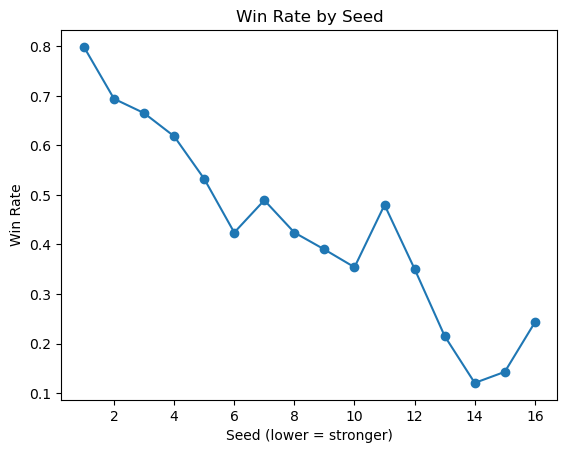

In [90]:
# When a team has seed X, how often do they win?

teamA = matchups[["TeamA_Seed", "Y"]].rename(columns={"TeamA_Seed": "Seed", "Y": "Win"})
teamB = matchups[["TeamB_Seed", "Y"]].rename(columns={"TeamB_Seed": "Seed", "Y": "Win"})

# For teamB, Y=1 means TeamA won and teamB lost. we want to flip this;
teamB["Win"] = 1 - teamB["Win"]

# Combine
seed_perf = pd.concat([teamA, teamB])

# Compute win rate
seed_winrate = seed_perf.groupby("Seed")["Win"].mean().reset_index()

print(seed_winrate)

plt.figure()
plt.plot(seed_winrate["Seed"], seed_winrate["Win"], marker='o')
plt.xlabel("Seed (lower = stronger)")
plt.ylabel("Win Rate")
plt.title("Win Rate by Seed")
plt.show()


Generally follows a good trend that lower seed is higher winrate, with a few anomalies like increasing from 14, 15, 16, and sudden spike at seed 7 and 11.
* We can kind of confirm that seed is indeed a strong predictor.

Now checking seedDiff vs winrate: basically measuring strength between 2 teams when they play. by right lower seed should win more

   SeedDiff         Y
0       -15  0.972222
1       -13  0.902778
2       -12  0.800000
3       -11  0.886076
4       -10  0.625000


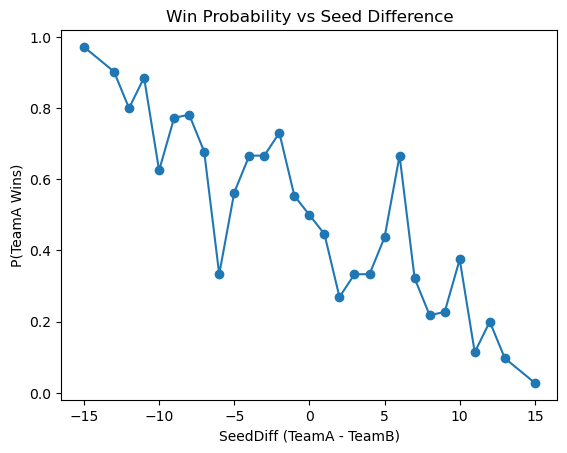

In [91]:
seed_diff_perf = matchups.groupby("SeedDiff")["Y"].mean().reset_index()
print(seed_diff_perf.head())

plt.figure()
plt.plot(seed_diff_perf["SeedDiff"], seed_diff_perf["Y"], marker='o')
plt.xlabel("SeedDiff (TeamA - TeamB)")
plt.ylabel("P(TeamA Wins)")
plt.title("Win Probability vs Seed Difference")
plt.show()

Trend is generally okay here also. Difference in seed between 2 teams show a strong relationship with match outcomes, where teams with better seeds generally have a higher probability of winning.
* SeedDiff is indeed useful for the model as -ve seedDiff has higher win probability than positive one, means the team that is expected to win wins more often than lose.

## Phase 3: Data Prepping for seasonal statistics for points conceded/scored per team

### 3a. create a team-game dataset, we want 1 row per team per game.

In [92]:
regular_results.head()

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,...,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
13862,2006,8,1165,75,1384,54,N,0,24,54,...,20,11,17,11,19,11,12,5,4,18
13863,2006,8,1393,68,1126,37,H,0,21,44,...,13,4,9,12,19,10,23,13,1,24
13864,2006,9,1107,90,1324,73,N,0,35,62,...,25,7,12,18,16,13,18,11,7,15
13865,2006,9,1126,63,1384,52,N,1,22,59,...,26,12,19,20,35,11,17,3,4,16
13866,2006,9,1196,80,1389,51,H,0,29,54,...,18,3,8,16,22,10,17,4,0,20


In [93]:
# Winner perspective 

games_w = pd.DataFrame({
    "Season": regular_results["Season"],
    "TeamID": regular_results["WTeamID"],
    "OpponentID": regular_results["LTeamID"],
    "PointsScored": regular_results["WScore"],
    "PointsAllowed": regular_results["LScore"],
    "Win": 1
})

# Loser perspective 
games_l = pd.DataFrame({
    "Season": regular_results["Season"],
    "TeamID": regular_results["LTeamID"],
    "OpponentID": regular_results["WTeamID"],
    "PointsScored": regular_results["LScore"],
    "PointsAllowed": regular_results["WScore"],
    "Win": 0
})

# Combine
team_games = pd.concat([games_w, games_l], ignore_index=True)
team_games.head()

,Season,TeamID,OpponentID,PointsScored,PointsAllowed,Win
0,2006,1165,1384,75,54,1
1,2006,1393,1126,68,37,1
2,2006,1107,1324,90,73,1
3,2006,1126,1384,63,52,1
4,2006,1196,1389,80,51,1


### 3b. aggregate into team stats by computing averages per team per season

In [94]:
team_stats = team_games.groupby(["Season", "TeamID"]).agg({
    "PointsScored": "mean",
    "PointsAllowed": "mean",
    "Win": "mean"
}).reset_index()

# Renaming
team_stats = team_stats.rename(columns={
    "Win": "WinRate", 
    "PointsScored": "AvgPointsScored",
    "PointsAllowed": "AvgPointsAllowed"
})
team_stats.head()

,Season,TeamID,AvgPointsScored,AvgPointsAllowed,WinRate
0,2006,1102,63.500000,54.571429,0.785714
1,2006,1103,71.466667,66.133333,0.700000
2,2006,1104,69.965517,67.137931,0.586207
3,2006,1105,73.956522,72.652174,0.478261
4,2006,1106,66.166667,70.566667,0.400000


### 3c. Merge team stats into matchups from phase 2

In [95]:
# TeamA merge
matchups = matchups.merge(team_stats, left_on=["Season", "TeamA"], right_on=["Season", "TeamID"], how="left").rename(columns={
    "AvgPointsScored": "TeamA_AvgPointsScored",
    "AvgPointsAllowed": "TeamA_AvgPointsAllowed",
    "WinRate": "TeamA_WinRate"
})
matchups = matchups.drop(columns=["TeamID"])

# TeamB merge
matchups = matchups.merge(team_stats, left_on=["Season", "TeamB"], right_on=["Season", "TeamID"], how="left").rename(columns={
    "AvgPointsScored": "TeamB_AvgPointsScored",
    "AvgPointsAllowed": "TeamB_AvgPointsAllowed",
    "WinRate": "TeamB_WinRate"
})
matchups = matchups.drop(columns=["TeamID"])
matchups.head()

,Season,DayNum,TeamA,TeamB,Y,TeamA_Seed,TeamB_Seed,SeedDiff,TeamA_AvgPointsScored,TeamA_AvgPointsAllowed,TeamA_WinRate,TeamB_AvgPointsScored,TeamB_AvgPointsAllowed,TeamB_WinRate
0,2009,137,1199,1458,0,5,12,-7,68.617647,65.000000,0.735294,64.387097,59.000000,0.612903
1,2021,146,1166,1211,0,5,1,4,76.964286,68.285714,0.714286,92.115385,69.115385,1.000000
2,2018,137,1308,1155,0,12,5,7,75.600000,64.733333,0.833333,73.281250,65.812500,0.718750
3,2018,136,1460,1397,0,14,3,11,71.312500,66.156250,0.718750,74.212121,66.393939,0.757576
4,2023,139,1211,1395,1,3,6,-3,86.500000,73.875000,0.843750,75.181818,67.909091,0.636364


### 3d. Create diff features between A and B
* Always use diff is better because we always are asking "is teamA stronger than teamB?" so all the features used need to be comparative in nature.

In [96]:
matchups["PointsScored_Diff"] = matchups["TeamA_AvgPointsScored"] - matchups["TeamB_AvgPointsScored"]
matchups["PointsAllowed_Diff"] = matchups["TeamA_AvgPointsAllowed"] - matchups["TeamB_AvgPointsAllowed"]
matchups["WinRate_Diff"] = matchups["TeamA_WinRate"] - matchups["TeamB_WinRate"]

matchups.head()


,Season,DayNum,TeamA,TeamB,Y,TeamA_Seed,TeamB_Seed,SeedDiff,TeamA_AvgPointsScored,TeamA_AvgPointsAllowed,TeamA_WinRate,TeamB_AvgPointsScored,TeamB_AvgPointsAllowed,TeamB_WinRate,PointsScored_Diff,PointsAllowed_Diff,WinRate_Diff
0,2009,137,1199,1458,0,5,12,-7,68.617647,65.000000,0.735294,64.387097,59.000000,0.612903,4.230550,6.000000,0.122391
1,2021,146,1166,1211,0,5,1,4,76.964286,68.285714,0.714286,92.115385,69.115385,1.000000,-15.151099,-0.829670,-0.285714
2,2018,137,1308,1155,0,12,5,7,75.600000,64.733333,0.833333,73.281250,65.812500,0.718750,2.318750,-1.079167,0.114583
3,2018,136,1460,1397,0,14,3,11,71.312500,66.156250,0.718750,74.212121,66.393939,0.757576,-2.899621,-0.237689,-0.038826
4,2023,139,1211,1395,1,3,6,-3,86.500000,73.875000,0.843750,75.181818,67.909091,0.636364,11.318182,5.965909,0.207386


### Above are the 2 most important features: seed difference and points conceded/scored. we will add a few more features then can refine it later, through various methods. 

### Phase 4. Additional features
#### Remember all our stats need to be comparative in nature, i.e. vs our opponent's statistics. so its all "diff based".
1. Shooting efficiency: FG_pct = FGM / FGA --> positive means better shooting
2. 3-point efficiencty: FG3_pct = FGM3/FGA3 --> positive means stronger perimeter strength
3. Rebound: Rebounds = OR+DR --> positive means possession advantage
4. Turnovers --> expect negative as more turnovers = worse
5. Assists --> expect positive means better teamwork

In [97]:
# Winner perspective
games_w = pd.DataFrame({
    "Season": regular_results["Season"],
    "TeamID": regular_results["WTeamID"],
    "OpponentID": regular_results["LTeamID"],
    "PointsScored": regular_results["WScore"],
    "PointsAllowed": regular_results["LScore"],
    "Win": 1,
    "FGM": regular_results["WFGM"],
    "FGA": regular_results["WFGA"],
    "FGM3": regular_results["WFGM3"],
    "FGA3": regular_results["WFGA3"],
    "OR": regular_results["WOR"],
    "DR": regular_results["WDR"],
    "TO": regular_results["WTO"],
    "AST": regular_results["WAst"]
})

# Loser perspective
games_l = pd.DataFrame({
    "Season": regular_results["Season"],
    "TeamID": regular_results["LTeamID"],
    "OpponentID": regular_results["WTeamID"],
    "PointsScored": regular_results["LScore"],
    "PointsAllowed": regular_results["WScore"],
    "Win": 0,
    "FGM": regular_results["LFGM"],
    "FGA": regular_results["LFGA"],
    "FGM3": regular_results["LFGM3"],
    "FGA3": regular_results["LFGA3"],
    "OR": regular_results["LOR"],
    "DR": regular_results["LDR"],
    "TO": regular_results["LTO"],
    "AST": regular_results["LAst"]
})

# Combine
team_games = pd.concat([games_w, games_l], ignore_index=True)

# Aggregate to team-season level
team_stats = team_games.groupby(["Season", "TeamID"]).agg({
    "PointsScored": "mean",
    "PointsAllowed": "mean",
    "Win": "mean",
    "FGM": "mean",
    "FGA": "mean",
    "FGM3": "mean",
    "FGA3": "mean",
    "OR": "mean",
    "DR": "mean",
    "TO": "mean",
    "AST": "mean"
}).reset_index()

# Rename column
team_stats = team_stats.rename(columns={
    "PointsScored": "AvgPointsScored",
    "PointsAllowed": "AvgPointsAllowed",
    "Win": "WinRate"
})

# Derived features
team_stats["FG_pct"] = team_stats["FGM"] / team_stats["FGA"].replace(0, 1)
team_stats["FG3_pct"] = team_stats["FGM3"] / team_stats["FGA3"].replace(0, 1)
team_stats["Rebounds"] = team_stats["OR"] + team_stats["DR"]

# Remove irrelevant columns
team_stats_small = team_stats[[
    "Season", "TeamID",
    "FG_pct", "FG3_pct", "Rebounds", "TO", "AST"
]]

# TeamA Merge
matchups = matchups.merge(
    team_stats_small,
    left_on=["Season", "TeamA"],
    right_on=["Season", "TeamID"],
    how="left"
).rename(columns={
    "FG_pct": "TeamA_FG_pct",
    "FG3_pct": "TeamA_FG3_pct",
    "Rebounds": "TeamA_Rebounds",
    "TO": "TeamA_TO",
    "AST": "TeamA_AST"
})
matchups = matchups.drop(columns=["TeamID"])

# TeamB Merge
matchups = matchups.merge(
    team_stats_small,
    left_on=["Season", "TeamB"],
    right_on=["Season", "TeamID"],
    how="left"
).rename(columns={
    "FG_pct": "TeamB_FG_pct",
    "FG3_pct": "TeamB_FG3_pct",
    "Rebounds": "TeamB_Rebounds",
    "TO": "TeamB_TO",
    "AST": "TeamB_AST"
})

# new diff features
matchups["FG_pct_Diff"] = matchups["TeamA_FG_pct"] - matchups["TeamB_FG_pct"]
matchups["FG3_pct_Diff"] = matchups["TeamA_FG3_pct"] - matchups["TeamB_FG3_pct"]
matchups["Rebounds_Diff"] = matchups["TeamA_Rebounds"] - matchups["TeamB_Rebounds"]
matchups["TO_Diff"] = matchups["TeamA_TO"] - matchups["TeamB_TO"]
matchups["AST_Diff"] = matchups["TeamA_AST"] - matchups["TeamB_AST"]

print(matchups.columns)

Index(['Season', 'DayNum', 'TeamA', 'TeamB', 'Y', 'TeamA_Seed', 'TeamB_Seed',
       'SeedDiff', 'TeamA_AvgPointsScored', 'TeamA_AvgPointsAllowed',
       'TeamA_WinRate', 'TeamB_AvgPointsScored', 'TeamB_AvgPointsAllowed',
       'TeamB_WinRate', 'PointsScored_Diff', 'PointsAllowed_Diff',
       'WinRate_Diff', 'TeamA_FG_pct', 'TeamA_FG3_pct', 'TeamA_Rebounds',
       'TeamA_TO', 'TeamA_AST', 'TeamID', 'TeamB_FG_pct', 'TeamB_FG3_pct',
       'TeamB_Rebounds', 'TeamB_TO', 'TeamB_AST', 'FG_pct_Diff',
       'FG3_pct_Diff', 'Rebounds_Diff', 'TO_Diff', 'AST_Diff'],
      dtype='object')


## Phase 5. Final feature list

In [98]:
features = [
    "SeedDiff",
    "WinRate_Diff",
    "PointsScored_Diff",
    "PointsAllowed_Diff",
    "FG_pct_Diff",
    "FG3_pct_Diff",
    "Rebounds_Diff",
    "TO_Diff",
    "AST_Diff" 
]

X = matchups[features]
y = matchups["Y"]


In [99]:
X

,SeedDiff,WinRate_Diff,PointsScored_Diff,PointsAllowed_Diff,FG_pct_Diff,FG3_pct_Diff,Rebounds_Diff,TO_Diff,AST_Diff
0,-7,0.122391,4.230550,6.000000,-0.007476,-0.025765,4.785579,5.547438,0.071157
1,4,-0.285714,-15.151099,-0.829670,-0.075048,0.001894,-2.892857,-1.137363,-2.450549
2,7,0.114583,2.318750,-1.079167,0.003589,-0.026629,5.531250,0.172917,0.579167
3,11,-0.038826,-2.899621,-0.237689,-0.008370,-0.043642,0.067235,0.850379,-2.599432
4,-3,0.207386,11.318182,5.965909,0.064974,0.077418,0.101326,-1.539773,0.006629
...,...,...,...,...,...,...,...,...,...
2375,-1,0.145276,-0.188948,1.335116,-0.017296,0.019249,-1.607843,-1.072193,0.847594
2376,8,-0.023569,-4.521886,-5.686869,-0.017741,-0.021025,7.407407,0.555556,-3.252525
2377,5,-0.020499,-11.789661,-3.320856,-0.028873,-0.009066,-4.535651,0.989305,-5.400178
2378,-3,0.147917,-9.202083,-12.341667,0.010671,-0.001924,-2.858333,-2.154167,-2.791667


In [100]:
y

0       0
1       0
2       0
3       0
4       1
       ..
2375    0
2376    1
2377    1
2378    0
2379    1
Name: Y, Length: 2380, dtype: int64

### Phase 6. Log Regression BaseLine Model

### First try with all our features

In [101]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, log_loss, roc_curve, roc_auc_score
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Log Loss:", log_loss(y_test, y_prob))
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob)
auc_log = roc_auc_score(y_test, y_prob)
print("AUC:", auc_log)

Accuracy: 0.7037815126050421
Log Loss: 0.5615030693614175
AUC: 0.774920353982301


##### AUC Curve plot

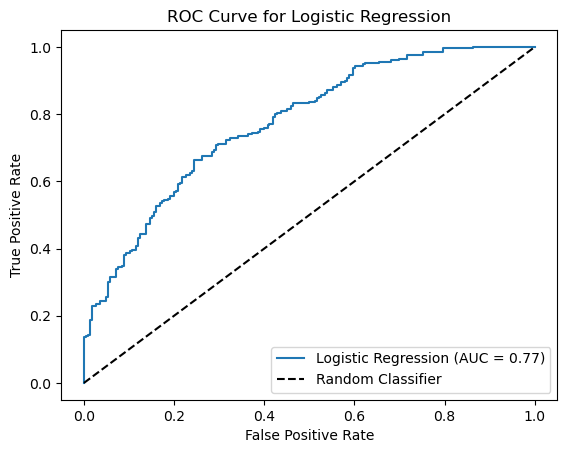

In [102]:
plt.figure()
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {auc_log:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression')
plt.legend()
plt.show()

In [103]:
coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient", key=abs, ascending=False)

print(coef_df.to_string(index=False))

           Feature  Coefficient
      FG3_pct_Diff    -1.002691
      WinRate_Diff    -0.727820
       FG_pct_Diff    -0.209325
          SeedDiff    -0.119547
 PointsScored_Diff     0.090842
PointsAllowed_Diff    -0.087959
          AST_Diff    -0.029895
           TO_Diff    -0.021268
     Rebounds_Diff    -0.018799


We expect only seedDiff and TO_diff to be -ve.
We expect the rest to be +ve.

But Why are they all negative?
likely multicollinearity, that the features are highly correlated and the model shares importance across features, causing the coefficients to flip signs.

Let's analyze the correlation matrix 

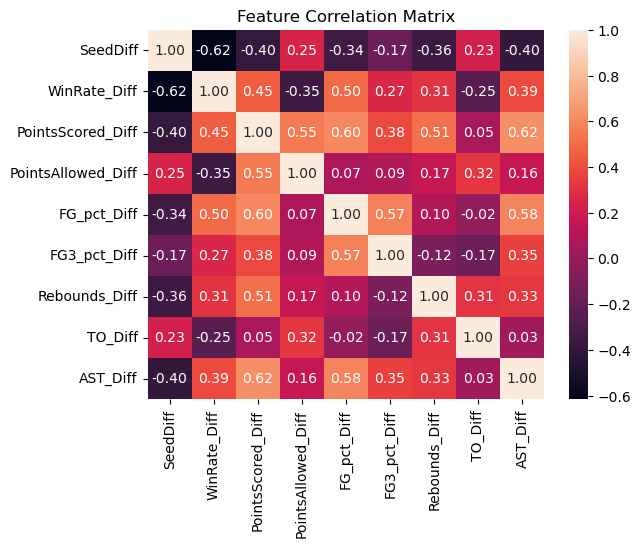

In [104]:
corr = matchups[[
    "SeedDiff",
    "WinRate_Diff",
    "PointsScored_Diff",
    "PointsAllowed_Diff",
    "FG_pct_Diff",
    "FG3_pct_Diff",
    "Rebounds_Diff",
    "TO_Diff",
    "AST_Diff"
]].corr()

plt.figure()
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

In [131]:
for feature in [
    "SeedDiff", "WinRate_Diff", "FG_pct_Diff",
    "FG3_pct_Diff", "TO_Diff", "AST_Diff",
    "PointsScored_Diff", "Rebounds_Diff"
]:
    X_single = matchups[[feature]]
    y = matchups["Y"]

    model = LogisticRegression(max_iter=1000)
    model.fit(X_single, y)

    print(feature, model.coef_[0][0])

SeedDiff -0.15185731573675978
WinRate_Diff 4.6502105681913735
FG_pct_Diff 4.725311611561136
FG3_pct_Diff 2.0621403833231993
TO_Diff -0.15723044166731928
AST_Diff 0.1508787041037285
PointsScored_Diff 0.06022853508425032
Rebounds_Diff 0.0885166538376519


This phenomenon can be attributed to multicollinearity among the predictor variables. Several features in the model capture similar aspects of team strength. For example, win rate, seed ranking, and scoring metrics are all highly correlated indicators of overall team performance. Similarly, field goal percentage and points scored are closely related measures of offensive efficiency.

To validate this, a correlation matrix of the input features was constructed, which revealed strong pairwise correlations among multiple predictors. Furthermore, when individual features were tested in isolation using logistic regression, their coefficients aligned with intuitive expectations. However, when combined in a multivariate model, the presence of overlapping information caused instability in coefficient estimation.

As a result, the logistic regression model distributes explanatory power across correlated variables, sometimes assigning negative coefficients to compensate for redundancy among features. This does not indicate that the variables are negatively related to winning, but rather reflects the model’s attempt to balance overlapping signals.

### Phase 6b. Refining our log reg model

We will remove 1 of each highly correlated features pair. the ones that rank the highest right now are:
1. WinRate_Diff and SeedDiff
2. PointsScored_Diff and AST_Diff
3. PointsScored_Diff and FG_PCT_DIFF
4. FG_pct_Diff and AST_Diff
5. FG3_pct_Diff and FG_Diff
6. PointsScored_Diff and PointsAllowed_Diff

Based on this, we will remove:
1. WinRate_Diff --> overlap with seedDiff and seedDiff is quite impt
2. FG_pct_Diff --> alot of overlaps
3. FG3_pct_Diff --> noisy
4. AST_Diff --> alot of overlaps
5. PointsScored_Diff --> Overlap with pointsAllowed_Diff and Rebounds_diff abit too much (0.55 and 0.51 respectively)

Rationale to keep the rest: 
1. "SeedDiff",            # overall strength
2. "PointsAllowed_Diff",   # defense
3. "Rebounds_Diff",       # control
4. "TO_Diff"              # discipline

Basically, different aspects of a team

In [106]:
features_final = [
    "SeedDiff",            # overall strength
    "PointsAllowed_Diff",   # defense
    "Rebounds_Diff",       # control
    "TO_Diff"              # discipline
]

In [107]:
X = matchups[features_final]
y = matchups["Y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob)
auc_log = roc_auc_score(y_test, y_prob)
acc_log = accuracy_score(y_test, y_pred)
ll_log = log_loss(y_test, y_prob)

print("Accuracy:", acc_log)
print("Log Loss:", ll_log)
print("AUC:", auc_log)


Accuracy: 0.6974789915966386
Log Loss: 0.5676718852461382
AUC: 0.7703185840707965


##### Plot AUC curve for log reg model

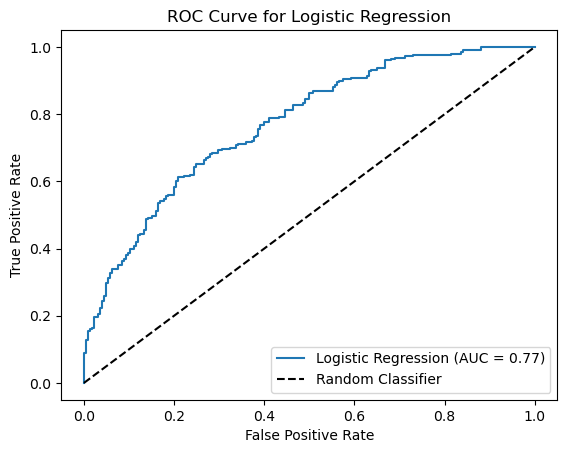

In [108]:
plt.figure()
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {auc_log:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression')
plt.legend()
plt.show()

Earlier with full-feature model:
* Accuracy: 0.7037815126050421
* Log Loss: 0.5615030693614175
* AUC: 0.774920353982301 <br>

Notice how we didn't manage to lose much accuracy and gain much log loss, which shows the features we removed are indeed redundant due to their high correlation to existing features.


In [109]:
coef_df = pd.DataFrame({
    "Feature": features_final,
    "Coefficient": model.coef_[0]
})

# coef_df["Coefficient"] = -coef_df["Coefficient"]
print(coef_df)

              Feature  Coefficient
0            SeedDiff    -0.140064
1  PointsAllowed_Diff    -0.020361
2       Rebounds_Diff     0.025117
3             TO_Diff    -0.060504


### Better correlation matrix using hand-picked features

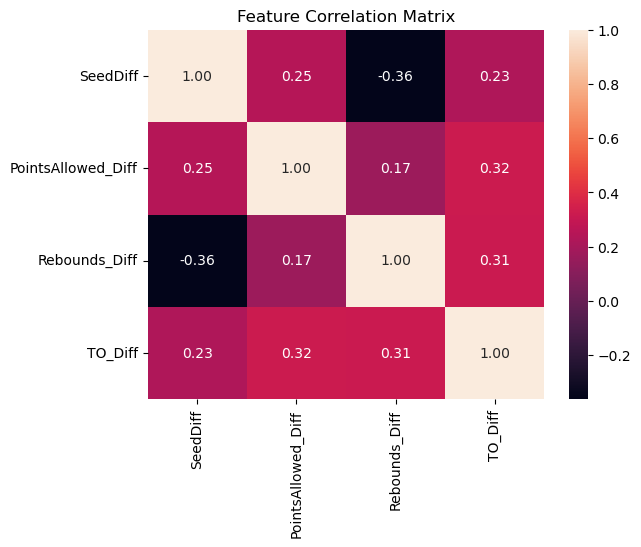

In [110]:
corr = matchups[[
    "SeedDiff",
    "PointsAllowed_Diff",
    "Rebounds_Diff",
    "TO_Diff",
]].corr()

plt.figure()
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

Now it makes more sense and is intepretable. 

1. SeedDiff (negative): tournament seeding captures overall team strength
2. PointsAllowedDiff (negative): defense matters, allowing fewer points increases win probability
3. TO_diff (negative): turnovers hurt, and ball control and possession is important to win
4. Rebounds_Diff (positive): more rebounds = more chances = higher win probability

Conclusion: The final logistic regression model achieved an accuracy of approximately X% and a log loss of Y, indicating reasonable predictive performance. Among the features, seed difference emerged as the strongest predictor, suggesting that tournament seeding effectively captures team strength.

In addition, defensive performance metrics were significant. Teams with lower points conceded exhibited a higher probability of winning. Turnover difference also showed a negative relationship with winning probability, indicating that teams that commit fewer turnovers perform better.

Rebounding differences contributed positively, suggesting that control of possession plays a role in match outcomes. 

## Phase 7. Adding different Models for comparisons and fine tuning for each model

Recall our final feature set: 
1. "SeedDiff",            # overall strength
2. "PointsAllowed_Diff",   # defense
3. "Rebounds_Diff",       # control
4. "TO_Diff"              # discipline

want to see if more complex models improve performance beyond logistic regression.

Right now our metrics:

Accuracy: 0.6974789915966386 <br>
Log Loss: 0.5676718852461382 <br>
AUC: 0.7703185840707965




We will also perform gridSearchCV to tune the parameters that gives the best outcome for Accuracy, LogLoss and AUC, and compare them.

Conduct hyperparameter tuning using GridSearchCV with 5-fold cross validation. This ensures that model performance is evaluated on unseen data during training, reducing the risk of overfitting and improving robustness of parameter selection.

In [111]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

### 7a. Try to improve our Logistic Regression model using Grid Search.

For log reg, the main tuning is for parameter C.

In [112]:
logreg = LogisticRegression(max_iter=2000)

logreg_param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"],
    "solver": ["lbfgs"]
}

grid_logreg = GridSearchCV(
    estimator=logreg,
    param_grid=logreg_param_grid,
    scoring="neg_log_loss",
    cv=5,
    n_jobs=-1
)

grid_logreg.fit(X_train, y_train)

print("Best Logistic params:", grid_logreg.best_params_)
print("Best Logistic CV score:", -grid_logreg.best_score_)

Best Logistic params: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Best Logistic CV score: 0.5726262526301648


### 7b. Try: Decision Tree (non-linear)

In [113]:
tree = DecisionTreeClassifier(random_state=42)

tree_param_grid = {
    "max_depth": [2, 3, 4, 5, 6, 8, 10],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10]
}

grid_tree = GridSearchCV(
    estimator=tree,
    param_grid=tree_param_grid,
    scoring="neg_log_loss",
    cv=5,
    n_jobs=-1
)

grid_tree.fit(X_train, y_train)

print("Best Tree params:", grid_tree.best_params_)
print("Best Tree CV score:", -grid_tree.best_score_)

Best Tree params: {'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Tree CV score: 0.5921436012937779


### 7c. Try: Random Foresst, robust ensemble

In [114]:
rf = RandomForestClassifier(random_state=42)

rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5]
}

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=rf_param_grid,
    scoring="neg_log_loss",
    cv=5,
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best RF params:", grid_rf.best_params_)
print("Best RF CV score:", -grid_rf.best_score_)

Best RF params: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 300}
Best RF CV score: 0.581345919980286


### 7d. Try: XGBoost

In [115]:
xgb = XGBClassifier(
    eval_metric="logloss",
    random_state=42
)

xgb_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [2, 3, 4, 5],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=xgb_param_grid,
    scoring="neg_log_loss",
    cv=5,
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

print("Best XGB params:", grid_xgb.best_params_)
print("Best XGB CV score:", -grid_xgb.best_score_)

Best XGB params: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100, 'subsample': 0.8}
Best XGB CV score: 0.5781223163440993


Rationale for grid size: only have 4 features, so not worth it to have huge grids. <br>
We use ```scoring=neg_log_loss``` for the gridsearchCV as our task is about predicting probabilities, not just labels. so log loss is the best main tuning metric here.  

Purpose of tuning: improved the robustness of the model comparison by ensuring that each algorithm was evaluated under a reasonable set of hyperparameters rather than relying on defaults. This is especially important for tree-based models, whose performance can vary substantially depending on depth and ensemble size.

### Phase 8. Comparing between models using each model's best, on the test set

In [116]:
best_models = {
    "Logistic Regression": grid_logreg.best_estimator_,
    "Decision Tree": grid_tree.best_estimator_,
    "Random Forest": grid_rf.best_estimator_,
    "XGBoost": grid_xgb.best_estimator_
}

results = []

for name, model in best_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    ll = log_loss(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "LogLoss": ll,
        "AUC": auc
    })

results_df = pd.DataFrame(results).sort_values(by="LogLoss")
print(results_df)

                 Model  Accuracy   LogLoss       AUC
0  Logistic Regression  0.693277  0.567953  0.770460
3              XGBoost  0.672269  0.570044  0.772027
2        Random Forest  0.689076  0.573031  0.772726
1        Decision Tree  0.674370  0.585371  0.744858


#### ROC plot for tuned models

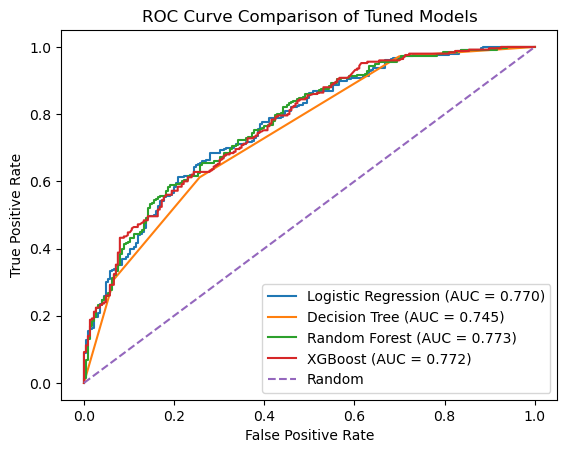

In [117]:
plt.figure()

for name, model in best_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Tuned Models")
plt.legend()
plt.show()

The performance of the four models after hyperparameter tuning is summarized in Table above.

Logistic regression achieved the best overall performance, with the highest accuracy (0.693) and lowest log loss (0.568). Random Forest and XGBoost achieved slightly higher ROC-AUC scores (~0.773), indicating marginally better ranking ability. However, these improvements did not translate into better accuracy or log loss.

The decision tree model performed the worst across all metrics, with lower accuracy and significantly higher log loss, indicating poorer generalization.

Overall, the differences between logistic regression and the ensemble models were relatively small.

The results suggest that logistic regression is sufficient for this prediction task. Despite the use of more complex models such as Random Forest and XGBoost, only marginal improvements were observed in ROC-AUC, with no meaningful gains in accuracy or log loss.

This can be explained by the nature of the feature set. The selected features — seed difference, defensive performance, rebounding, and turnovers — already capture the primary factors influencing match outcomes. These variables exhibit largely linear relationships with the target variable, limiting the benefit of models designed to capture non-linear interactions.

Additionally, the small number of features reduces the capacity for tree-based models to exploit complex interactions. As a result, increasing model complexity leads to diminishing returns.

These findings highlight that feature quality is more important than model complexity in this context. A simple, interpretable model such as logistic regression can perform as well as, or better than, more advanced machine learning models.

#### Random forest feature importance

In [118]:
rf_importance_df = pd.DataFrame({
    "Feature": features_final,
    "Importance": grid_rf.best_estimator_.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(rf_importance_df)

              Feature  Importance
0            SeedDiff    0.674341
2       Rebounds_Diff    0.130423
1  PointsAllowed_Diff    0.101595
3             TO_Diff    0.093641


#### XGBoost feature importance

In [119]:
xgb_importance_df = pd.DataFrame({
    "Feature": features_final,
    "Importance": grid_xgb.best_estimator_.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(xgb_importance_df)

              Feature  Importance
0            SeedDiff    0.673627
1  PointsAllowed_Diff    0.119349
3             TO_Diff    0.106673
2       Rebounds_Diff    0.100351


### Main Evaluation: Rolling-Origin by Tournament Season (No Random Split)

For each target tournament season $Y$ (2007 to 2024, excluding 2020):
- Train labels: tournament seasons `< Y`
- Test labels: tournament season `== Y`
- Features for season $Y$: built from regular-season information available up to that tournament season

This creates 17 yearly models in total and avoids temporal leakage.

In [36]:
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

features_final = [
    "SeedDiff",
    "PointsAllowed_Diff",
    "Rebounds_Diff",
    "TO_Diff"
 ]

X = matchups[features_final].copy()
y = matchups["Y"].copy()
season_series = matchups["Season"].copy()

# We only evaluate on tournament seasons 2007-2024, excluding 2020 (no tournament held).
TARGET_START = 2007
TARGET_END = 2024
desired_target_seasons = [s for s in range(TARGET_START, TARGET_END + 1) if s != 2020]

available_seasons = sorted(season_series.unique())
missing_target_seasons = [s for s in desired_target_seasons if s not in available_seasons]
if missing_target_seasons:
    raise ValueError(f"Missing target seasons in data: {missing_target_seasons}")

target_seasons = desired_target_seasons
print("Target seasons:", target_seasons)
print("Number of rolling target seasons:", len(target_seasons))

# Keep only seasons needed for this rolling evaluation (2006-2024 tournament rows).
final_train_mask = (season_series >= 2006) & (season_series <= TARGET_END)
X_cv = X.loc[final_train_mask].reset_index(drop=True)
y_cv = y.loc[final_train_mask].reset_index(drop=True)
season_cv = season_series.loc[final_train_mask].reset_index(drop=True)

def build_rolling_splits(season_data, targets):
    """
    For each target season Y:
      train = seasons < Y
      test = season == Y
    """
    splits = []
    for target in targets:
        train_idx = season_data[season_data < target].index.to_numpy()
        test_idx = season_data[season_data == target].index.to_numpy()

        if len(train_idx) == 0 or len(test_idx) == 0:
            continue

        splits.append((train_idx, test_idx))
    return splits

rolling_splits = build_rolling_splits(season_cv, target_seasons)
print("Number of rolling folds:", len(rolling_splits))

if len(rolling_splits) != 17:
    raise ValueError(
        f"Expected 17 rolling folds, but found {len(rolling_splits)}. Check season filters."
    )

# Grids are intentionally moderate so rolling GridSearch is computationally feasible.
model_builders = {
    "Logistic Regression": (
        LogisticRegression(max_iter=3000, random_state=42),
        {
            "C": [0.01, 0.1, 1, 10, 100],
            "penalty": ["l2"],
            "solver": ["lbfgs"]
        }
    ),
    "Decision Tree": (
        DecisionTreeClassifier(random_state=42),
        {
            "max_depth": [3, 4, 5, 6],
            "min_samples_split": [2, 10],
            "min_samples_leaf": [1, 5]
        }
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=42, n_jobs=-1),
        {
            "n_estimators": [200, 400],
            "max_depth": [4, 6, 8],
            "min_samples_split": [2, 10],
            "min_samples_leaf": [1, 3]
        }
    ),
    "XGBoost": (
        XGBClassifier(
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ),
        {
            "n_estimators": [100, 200],
            "max_depth": [2, 3],
            "learning_rate": [0.05, 0.1],
            "subsample": [0.8],
            "colsample_bytree": [0.8, 1.0]
        }
    )
}

rolling_results_all = {}
summary_rows = []

for model_name, (base_model, param_grid) in model_builders.items():
    print(f"\n=== {model_name} ===")

    grid = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        scoring="neg_log_loss",
        cv=rolling_splits,
        n_jobs=-1,
        refit=True
    )
    grid.fit(X_cv, y_cv)

    best_model = grid.best_estimator_
    print("Best params:", grid.best_params_)
    print("Best CV mean LogLoss:", -grid.best_score_)

    # Recompute fold-by-fold metrics using the best hyperparameters (17 rolling models).
    per_fold = []
    for target, (train_idx, test_idx) in zip(target_seasons, rolling_splits):
        model = clone(best_model)
        model.fit(X_cv.iloc[train_idx], y_cv.iloc[train_idx])

        y_test = y_cv.iloc[test_idx]
        y_pred = model.predict(X_cv.iloc[test_idx])
        y_prob = model.predict_proba(X_cv.iloc[test_idx])[:, 1]

        per_fold.append({
            "Model": model_name,
            "TargetSeason": target,
            "TestSize": len(test_idx),
            "Accuracy": accuracy_score(y_test, y_pred),
            "LogLoss": log_loss(y_test, y_prob),
            "AUC": roc_auc_score(y_test, y_prob)
        })

    season_df = pd.DataFrame(per_fold)
    rolling_results_all[model_name] = {
        "best_params": grid.best_params_,
        "best_estimator": best_model,
        "per_season": season_df
    }

    summary_rows.append({
        "Model": model_name,
        "BestParams": str(grid.best_params_),
        "Avg_Accuracy": season_df["Accuracy"].mean(),
        "Std_Accuracy": season_df["Accuracy"].std(ddof=1),
        "Avg_LogLoss": season_df["LogLoss"].mean(),
        "Std_LogLoss": season_df["LogLoss"].std(ddof=1),
        "Avg_AUC": season_df["AUC"].mean(),
        "Std_AUC": season_df["AUC"].std(ddof=1),
        "Num_Seasons": season_df["TargetSeason"].nunique()
    })

summary_df = pd.DataFrame(summary_rows).sort_values(by="Avg_LogLoss")
print("\nFinal averaged metrics across 17 rolling target seasons (best tuned params):")
print(summary_df.to_string(index=False))

# Optional: detailed per-season table for all models
per_season_results = pd.concat([
    rolling_results_all[name]["per_season"] for name in rolling_results_all
], ignore_index=True).sort_values(["TargetSeason", "Model"])

print("\nPer-season metrics (all models):")
print(per_season_results.to_string(index=False))

Target seasons: [2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2021, 2022, 2023, 2024]
Number of rolling target seasons: 17
Number of rolling folds: 17

=== Logistic Regression ===
Best params: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV mean LogLoss: 0.5751441023830184

=== Decision Tree ===
Best params: {'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best CV mean LogLoss: 0.7303661165324167

=== Random Forest ===
Best params: {'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}
Best CV mean LogLoss: 0.5768835498754793

=== XGBoost ===
Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100, 'subsample': 0.8}
Best CV mean LogLoss: 0.5768454671431071

Final averaged metrics across 17 rolling target seasons (best tuned params):
              Model                                                                                              BestParams  Avg_

In [27]:
pd.set_option("display.max_colwidth", None)
print(summary_df.to_string(index=False))

              Model                                                                                              BestParams  Avg_Accuracy  Std_Accuracy  Avg_LogLoss  Std_LogLoss  Avg_AUC  Std_AUC  Num_Seasons
Logistic Regression                                                         {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}      0.692283      0.057331     0.575144     0.054335 0.770720 0.056720           17
      Random Forest                    {'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}      0.694334      0.038481     0.576884     0.041984 0.770927 0.051233           17
            XGBoost {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100, 'subsample': 0.8}      0.691955      0.043825     0.578102     0.047488 0.767468 0.049534           17
      Decision Tree                                         {'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 2}      0.674972      0.030249     0.730366

### Rolling Feature Importance (Tree-Based Models)

Using the same rolling GridSearch workflow, we directly reuse the fitted best estimators returned by GridSearchCV (`refit=True`) for Random Forest and XGBoost, then report feature importances.

In [38]:
# Feature importance from best tree-based models (prefer existing fitted models, no extra refit when possible)
rf_required_best_params = {
    "max_depth": 4,
    "min_samples_leaf": 1,
    "min_samples_split": 2,
    "n_estimators": 400
}
xgb_required_best_params = {
    "colsample_bytree": 0.8,
    "learning_rate": 0.05,
    "max_depth": 2,
    "n_estimators": 100,
    "subsample": 0.8
}

rf_best = None
xgb_best = None

if "rolling_results_all" in globals():
    rf_best = rolling_results_all.get("Random Forest", {}).get("best_estimator")
    xgb_best = rolling_results_all.get("XGBoost", {}).get("best_estimator")

# Reuse already-fitted models from previous cells if available.
if rf_best is None and "rf_final" in globals():
    rf_best = rf_final
if xgb_best is None and "xgb_final" in globals():
    xgb_best = xgb_final

# Last-resort fallback: build using the required best params.
if rf_best is None:
    rf_best = RandomForestClassifier(random_state=42, n_jobs=-1, **rf_required_best_params)
    rf_best.fit(X_cv, y_cv)
if xgb_best is None:
    xgb_best = XGBClassifier(eval_metric="logloss", random_state=42, n_jobs=-1, **xgb_required_best_params)
    xgb_best.fit(X_cv, y_cv)

rf_importance_rolling = pd.DataFrame({
    "Feature": features_final,
    "RF_Importance": rf_best.feature_importances_
}).sort_values("RF_Importance", ascending=False)

xgb_importance_rolling = pd.DataFrame({
    "Feature": features_final,
    "XGB_Importance": xgb_best.feature_importances_
}).sort_values("XGB_Importance", ascending=False)

print("Random Forest feature importance (best estimator from rolling workflow):")
print(rf_importance_rolling.to_string(index=False))

print("\nXGBoost feature importance (best estimator from rolling workflow):")
print(xgb_importance_rolling.to_string(index=False))

feature_importance_compare = rf_importance_rolling.merge(
    xgb_importance_rolling,
    on="Feature",
    how="outer"
).sort_values("RF_Importance", ascending=False)

print("\nComparison table:")
print(feature_importance_compare.to_string(index=False))

Random Forest feature importance (best estimator from rolling workflow):
           Feature  RF_Importance
          SeedDiff       0.741103
     Rebounds_Diff       0.104423
           TO_Diff       0.081260
PointsAllowed_Diff       0.073214

XGBoost feature importance (best estimator from rolling workflow):
           Feature  XGB_Importance
          SeedDiff        0.614935
           TO_Diff        0.141073
PointsAllowed_Diff        0.126163
     Rebounds_Diff        0.117829

Comparison table:
           Feature  RF_Importance  XGB_Importance
          SeedDiff       0.741103        0.614935
     Rebounds_Diff       0.104423        0.117829
           TO_Diff       0.081260        0.141073
PointsAllowed_Diff       0.073214        0.126163


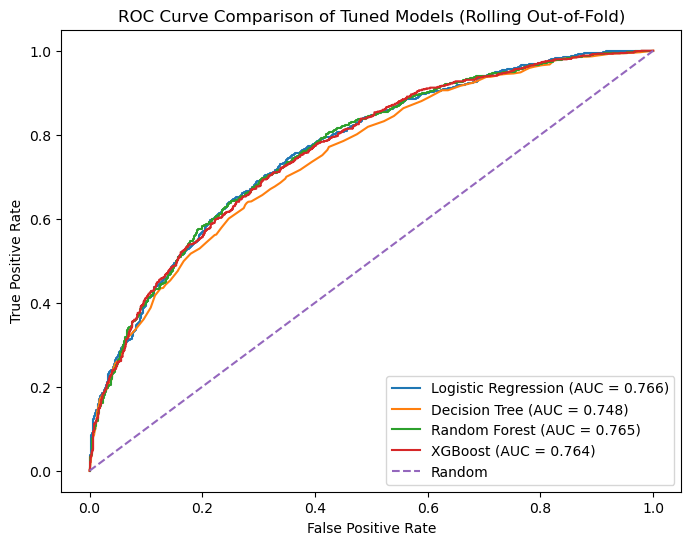

In [40]:
# Build models from best params found in rolling GridSearch.
best_models_rolling = {
    "Logistic Regression": LogisticRegression(
        max_iter=3000,
        random_state=42,
        **rolling_results_all["Logistic Regression"]["best_params"]
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        **rolling_results_all["Decision Tree"]["best_params"]
    ),
    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        **rolling_results_all["Random Forest"]["best_params"]
    ),
    "XGBoost": XGBClassifier(
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
        **rolling_results_all["XGBoost"]["best_params"]
    )
}

# Out-of-fold ROC over rolling splits: each target season contributes only test-fold predictions.
plt.figure(figsize=(8, 6))

for name, model in best_models_rolling.items():
    y_true_all = []
    y_prob_all = []

    for train_idx, test_idx in rolling_splits:
        model.fit(X_cv.iloc[train_idx], y_cv.iloc[train_idx])
        y_prob = model.predict_proba(X_cv.iloc[test_idx])[:, 1]

        y_true_all.extend(y_cv.iloc[test_idx].to_numpy())
        y_prob_all.extend(y_prob)

    y_true_all = np.array(y_true_all)
    y_prob_all = np.array(y_prob_all)

    fpr, tpr, _ = roc_curve(y_true_all, y_prob_all)
    auc = roc_auc_score(y_true_all, y_prob_all)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Tuned Models (Rolling Out-of-Fold)")
plt.legend()
plt.show()